# pyDRTtools local tutorial: synthetic EIS → DRT recovery

This notebook is for checking the local source tree. It does **not** install `pyDRTtools` from PyPI and it does **not** assume the package has been installed into the active environment. It imports the package directly from the repository folder by adding the repository root to `sys.path`.

The core validation target is deliberately simple and scientific: generate known synthetic spectra, run Simple/Bayesian DRT recovery, then check whether the recovered series resistance, total polarization resistance, peak time constants, fitted impedance, Bayesian credible intervals, and BHT / KK consistency-score status look reasonable. BHT scores may be available even when no validated BHT DRT estimate is available.

## What this notebook should prove

A good local run should demonstrate the following.

1. `R_inf + ZARC` synthetic spectra can be read without sign or column-index mistakes.
2. Ridge/Tikhonov DRT recovery gives a sensible `R_inf`, DRT peak near the true `tau`, and an impedance fit with small residuals.
3. A two-ZARC batch loop recovers the two expected DRT time-scale regions and tracks total polarization resistance.
4. Bayesian recovery returns finite, ordered credible bands.
5. BHT / KK consistency returns either finite scores or a clean failure status; it must not hang, and any BHT DRT remains unavailable unless explicitly validated.
6. The GUI can load the generated CSV files, run methods, plot results, export results, and survive cancelled exports.

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util
import json
import os
import subprocess
import sys


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root whether the notebook is launched from root or tutorial/."""

    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "pyDRTtools").is_dir():
            return candidate
    raise RuntimeError("Could not find the pyDRTtools repository root. Launch this notebook from the repo or tutorial folder.")


ROOT = find_project_root()
TUTORIAL_DIR = ROOT / "tutorial"
DATA_DIR = TUTORIAL_DIR / "data"

# Local-source import: this is the important part. No package installation is required.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repository root:", ROOT)
print("Tutorial data directory:", DATA_DIR)

Repository root: /Users/francesco/Library/CloudStorage/OneDrive-UniversitätBayreuth/software/DRT/pyDRTtools_1.10.02_clean
Tutorial data directory: /Users/francesco/Library/CloudStorage/OneDrive-UniversitätBayreuth/software/DRT/pyDRTtools_1.10.02_clean/tutorial/data


In [2]:
# Check dependencies early and fail clearly.
# These are project dependencies in the active Python environment; this cell does not install pyDRTtools.
required_modules = ["cvxopt", "numpy", "scipy", "pandas", "matplotlib", "sklearn"]
missing = [name for name in required_modules if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError(
        "Missing dependency/dependencies: " + ", ".join(missing) +
        ". Use a lab/conda environment that contains the project dependencies, then rerun the notebook."
    )

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from pyDRTtools import runs

# Keep quadratic-program output quiet in tutorial runs.
try:
    from cvxopt import solvers
    solvers.options["show_progress"] = False
except Exception:
    pass

## Generate or refresh the synthetic data

The old artificial-data notebook is replaced by a plain Python script, `tutorial/generate_artificial_eis_data.py`. It writes clean CSV files with columns `Freq`, `Real`, and `Imag`; the CSVs have no pandas index column. The `Imag` column is the signed imaginary part `Z''`, so capacitive values are negative.

In [4]:
generator = TUTORIAL_DIR / "generate_artificial_eis_data.py"
subprocess.run([sys.executable, str(generator)], check=True, cwd=str(ROOT))

with (DATA_DIR / "metadata.json").open("r", encoding="utf-8") as f:
    metadata = json.load(f)

summary_rows = []
for record in metadata["spectra"]:
    summary_rows.append({
        "file": record["filename"],
        "label": record["label"],
        "R_inf / ohm": record["R_inf_ohm"],
        "R_pol / ohm": record["R_pol_ohm"],
        "expected tau peaks / s": record["expected_tau_peaks_s"],
        "noise sigma / ohm": record["noise_sigma_ohm"],
    })

pd.DataFrame(summary_rows)

Wrote 8 spectra to /Users/francesco/Library/CloudStorage/OneDrive-UniversitätBayreuth/software/DRT/pyDRTtools_1.10.02_clean/tutorial/data
Metadata: /Users/francesco/Library/CloudStorage/OneDrive-UniversitätBayreuth/software/DRT/pyDRTtools_1.10.02_clean/tutorial/data/metadata.json


,file,label,R_inf / ohm,R_pol / ohm,expected tau peaks / s,noise sigma / ohm
0,1ZARC_exact.csv,"single ZARC, noiseless reference",10.0,50.0,[0.1],0.00
1,1ZARC.csv,"single ZARC, noisy",10.0,50.0,[0.1],0.05
2,2ZARC0.csv,"two ZARCs, slow resistance 5 ohm",10.0,55.0,"[0.1, 0.0001]",0.05
3,2ZARC1.csv,"two ZARCs, slow resistance 15 ohm",10.0,65.0,"[0.1, 0.0001]",0.05
4,2ZARC2.csv,"two ZARCs, slow resistance 25 ohm",10.0,75.0,"[0.1, 0.0001]",0.05
5,2ZARC3.csv,"two ZARCs, slow resistance 35 ohm",10.0,85.0,"[0.1, 0.0001]",0.05
6,2ZARC4.csv,"two ZARCs, slow resistance 45 ohm",10.0,95.0,"[0.1, 0.0001]",0.05
7,2ZARC5.csv,"two ZARCs, slow resistance 55 ohm",10.0,105.0,"[0.1, 0.0001]",0.05


In [5]:
def truth_for(filename: str) -> dict:
    for record in metadata["spectra"]:
        if record["filename"] == filename:
            return record
    raise KeyError(filename)


def load_frame(filename: str, *, every: int = 1) -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / filename).iloc[::every].reset_index(drop=True)


def load_entry(filename: str, *, every: int = 1) -> runs.EIS_object:
    df = load_frame(filename, every=every)
    return runs.EIS_object(df["Freq"].to_numpy(), df["Real"].to_numpy(), df["Imag"].to_numpy())


def trapezoid(y: np.ndarray, x: np.ndarray) -> float:
    fn = getattr(np, "trapezoid", None) or np.trapz
    return float(fn(y, x=x))


def sorted_tau_gamma(entry: runs.EIS_object, gamma: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray]:
    tau = np.asarray(entry.out_tau_vec, dtype=float).ravel()
    gamma = np.asarray(entry.gamma if gamma is None else gamma, dtype=float).ravel()
    order = np.argsort(tau)
    return tau[order], gamma[order]


def exact_zarc_drt_density(tau: np.ndarray, element: dict) -> np.ndarray:
    """Exact ZARC DRT density per natural log time for R/(1+(j*omega*tau0)**phi)."""

    tau = np.asarray(tau, dtype=float)
    R = float(element["R_ct_ohm"])
    tau0 = float(element["tau_s"])
    phi = float(element["phi"])
    if not (0.0 < phi < 1.0):
        raise ValueError(f"The continuous ZARC DRT formula requires 0 < phi < 1, got phi={phi}.")
    x = np.clip(phi * np.log(tau / tau0), -700.0, 700.0)
    denominator = np.cosh(x) + np.cos(np.pi * phi)
    return R * np.sin(np.pi * phi) / (2.0 * np.pi * denominator)


def exact_drt(tau: np.ndarray, truth: dict) -> np.ndarray:
    """Exact DRT density for the full synthetic spectrum, summed over all ZARC elements."""

    tau = np.asarray(tau, dtype=float)
    gamma_exact = np.zeros_like(tau, dtype=float)
    for element in truth["elements"]:
        gamma_exact += exact_zarc_drt_density(tau, element)
    return gamma_exact


def dense_tau_grid(tau: np.ndarray, *, n: int = 1200) -> np.ndarray:
    tau = np.asarray(tau, dtype=float)
    return np.logspace(np.log10(float(np.min(tau))), np.log10(float(np.max(tau))), n)


def drt_error_metrics(tau: np.ndarray, gamma: np.ndarray, truth: dict) -> dict[str, float]:
    gamma_exact = exact_drt(tau, truth)
    log_tau = np.log(tau)
    recovered_area = trapezoid(gamma, log_tau)
    exact_area_window = trapezoid(gamma_exact, log_tau)
    exact_l1 = max(trapezoid(np.abs(gamma_exact), log_tau), 1e-30)
    exact_l2 = max(np.sqrt(trapezoid(gamma_exact**2, log_tau)), 1e-30)
    return {
        "R_pol recovered over tau window / ohm": recovered_area,
        "R_pol exact over tau window / ohm": exact_area_window,
        "R_pol window relative error": abs(recovered_area - exact_area_window) / max(abs(exact_area_window), 1e-30),
        "DRT L1 relative error over tau window": trapezoid(np.abs(gamma - gamma_exact), log_tau) / exact_l1,
        "DRT L2 relative error over tau window": np.sqrt(trapezoid((gamma - gamma_exact) ** 2, log_tau)) / exact_l2,
    }


def run_simple(filename: str, *, rbf_type: str = "Gaussian", cv_type: str = "custom", reg_param: float = 1e-4) -> runs.EIS_object:
    entry = load_entry(filename)
    runs.simple_run(
        entry,
        rbf_type=rbf_type,
        data_used="Combined Re-Im Data",
        induct_used=0,
        der_used="1st order",
        cv_type=cv_type,
        reg_param=reg_param,
    )
    return entry


def recovery_metrics(entry: runs.EIS_object, truth: dict, *, peak_prominence: float = 0.02) -> dict:
    tau, gamma = sorted_tau_gamma(entry)
    expected_taus = np.asarray(truth["expected_tau_peaks_s"], dtype=float)
    z_fit = np.asarray(entry.mu_Z_re) + 1j * np.asarray(entry.mu_Z_im)

    peak_indices, _ = find_peaks(gamma, prominence=peak_prominence * max(float(np.max(gamma)), 1e-12))
    if peak_indices.size:
        recovered_taus = tau[peak_indices]
        tau_errors = [float(np.min(np.abs(np.log10(recovered_taus / tau0)))) for tau0 in expected_taus]
    else:
        tau_errors = [float("inf") for _ in expected_taus]

    exact_errors = drt_error_metrics(tau, gamma, truth)
    return {
        "R_inf recovered / ohm": float(entry.R),
        "R_inf relative error": abs(float(entry.R) - truth["R_inf_ohm"]) / truth["R_inf_ohm"],
        "R_pol recovered / ohm": trapezoid(gamma, np.log(tau)),
        "R_pol relative error vs full truth": abs(trapezoid(gamma, np.log(tau)) - truth["R_pol_ohm"]) / truth["R_pol_ohm"],
        **exact_errors,
        "max tau-peak error / decades": max(tau_errors),
        "relative impedance residual": float(np.linalg.norm(z_fit - entry.Z_exp) / np.linalg.norm(entry.Z_exp)),
        "lambda": float(entry.lambda_value),
        "number of detected peaks": int(peak_indices.size),
    }


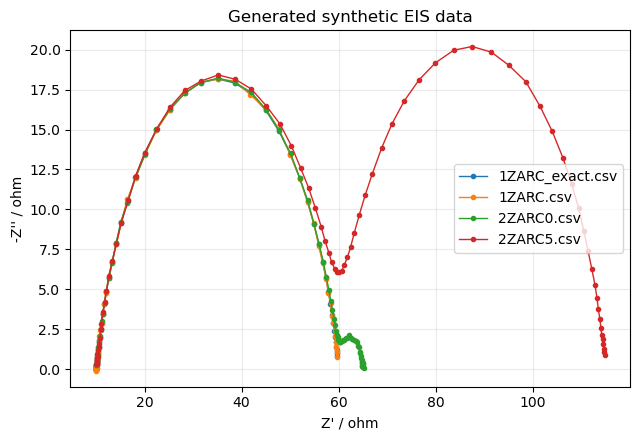

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for filename in ["1ZARC_exact.csv", "1ZARC.csv", "2ZARC0.csv", "2ZARC5.csv"]:
    df = load_frame(filename)
    ax.plot(df["Real"], -df["Imag"], marker="o", markersize=3, linewidth=1, label=filename)
ax.set_xlabel("Z' / ohm")
ax.set_ylabel("-Z'' / ohm")
ax.set_title("Generated synthetic EIS data")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()

## 1. Single `R_inf + ZARC` recovery

Start with the noiseless one-ZARC case. This should be the cleanest check that the matrices, sign convention, resistance term, and DRT basis are working together.

The DRT plots below compare the recovered DRT directly with the exact ZARC DRT density per natural log time.

\[
\gamma_k(\tau)=\frac{R_k\sin(\pi\phi_k)}{2\pi\left[\cosh\left(\phi_k\log(\tau/\tau_k)\right)+\cos(\pi\phi_k)\right]}.
\]

For spectra with two ZARC elements, the exact DRT is the sum of the two exact densities.


In [7]:
entry_exact = run_simple("1ZARC_exact.csv", rbf_type="Gaussian", cv_type="custom", reg_param=1e-4)
metrics_exact = recovery_metrics(entry_exact, truth_for("1ZARC_exact.csv"))

pd.DataFrame([metrics_exact]).T.rename(columns={0: "1ZARC exact"})

,1ZARC exact
R_inf recovered / ohm,9.981657
R_inf relative error,0.001834
R_pol recovered / ohm,50.143766
R_pol relative error vs full truth,0.002875
R_pol recovered over tau window / ohm,50.143766
R_pol exact over tau window / ohm,49.980977
R_pol window relative error,0.003257
DRT L1 relative error over tau window,0.062219
DRT L2 relative error over tau window,0.056262
max tau-peak error / decades,0.004326


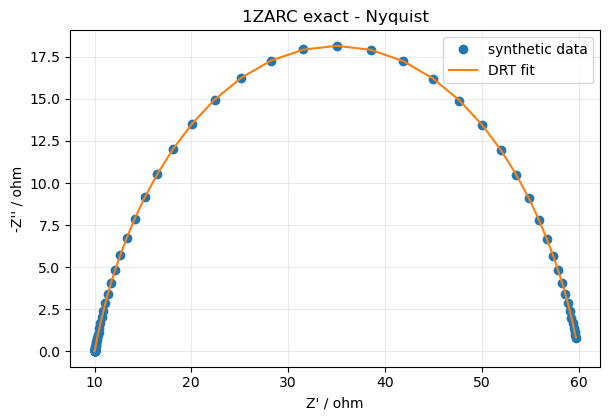

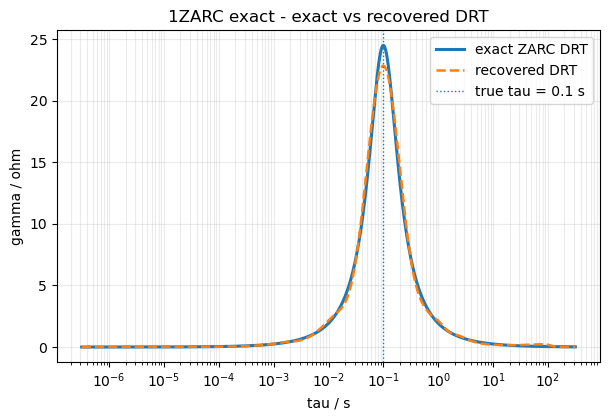

In [8]:
def plot_drt_exact_vs_recovered(
    entry: runs.EIS_object,
    truth: dict,
    title: str,
    *,
    gamma: np.ndarray | None = None,
    gamma_label: str = "recovered DRT",
    band: tuple[np.ndarray, np.ndarray] | None = None,
) -> None:
    tau, gamma_values = sorted_tau_gamma(entry, gamma=gamma)
    tau_dense = dense_tau_grid(tau)
    gamma_exact_dense = exact_drt(tau_dense, truth)

    fig, ax = plt.subplots(figsize=(6.2, 4.3))
    ax.semilogx(tau_dense, gamma_exact_dense, linewidth=2.2, label="exact ZARC DRT")
    ax.semilogx(tau, gamma_values, "--", linewidth=1.8, label=gamma_label)
    if band is not None:
        tau_raw = np.asarray(entry.out_tau_vec, dtype=float).ravel()
        order = np.argsort(tau_raw)
        lower = np.asarray(band[0], dtype=float).ravel()[order]
        upper = np.asarray(band[1], dtype=float).ravel()[order]
        ax.fill_between(tau, lower, upper, alpha=0.25, label="99% credible band")
    for tau0 in truth["expected_tau_peaks_s"]:
        ax.axvline(tau0, linestyle=":", linewidth=1.0, label=f"true tau = {tau0:g} s")
    ax.set_xlabel("tau / s")
    ax.set_ylabel("gamma / ohm")
    ax.set_title(title + " - exact vs recovered DRT")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
    fig.tight_layout()


def plot_simple_result(entry: runs.EIS_object, truth: dict, title: str) -> None:
    z_fit = np.asarray(entry.mu_Z_re) + 1j * np.asarray(entry.mu_Z_im)

    fig, ax = plt.subplots(figsize=(6.2, 4.3))
    ax.plot(entry.Z_exp.real, -entry.Z_exp.imag, "o", label="synthetic data")
    ax.plot(z_fit.real, -z_fit.imag, "-", label="DRT fit")
    ax.set_xlabel("Z' / ohm")
    ax.set_ylabel("-Z'' / ohm")
    ax.set_title(title + " - Nyquist")
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()

    plot_drt_exact_vs_recovered(entry, truth, title)


plot_simple_result(entry_exact, truth_for("1ZARC_exact.csv"), "1ZARC exact")


## 2. Noisy one-ZARC data and regularization selection

The noisy spectrum uses the same true circuit plus independent real/imaginary Gaussian noise. First run a fixed regularization parameter for reproducibility, then compare with a selected regularization parameter. The exact tolerances should be looser here than for the noiseless case.

In [9]:
entry_noisy_custom = run_simple("1ZARC.csv", rbf_type="Gaussian", cv_type="custom", reg_param=1e-4)
entry_noisy_gcv = run_simple("1ZARC.csv", rbf_type="Gaussian", cv_type="GCV", reg_param=1e-3)

pd.DataFrame(
    [
        {"case": "custom lambda", **recovery_metrics(entry_noisy_custom, truth_for("1ZARC.csv"))},
        {"case": "GCV lambda", **recovery_metrics(entry_noisy_gcv, truth_for("1ZARC.csv"))},
    ]
)

,case,R_inf recovered / ohm,R_inf relative error,R_pol recovered / ohm,R_pol relative error vs full truth,R_pol recovered over tau window / ohm,R_pol exact over tau window / ohm,R_pol window relative error,DRT L1 relative error over tau window,DRT L2 relative error over tau window,max tau-peak error / decades,relative impedance residual,lambda,number of detected peaks
0,custom lambda,9.989272,0.001073,50.153515,0.003070,50.153515,49.980977,0.003452,0.086584,0.066911,0.006799,0.002148,0.000100,1
1,GCV lambda,9.989043,0.001096,50.155105,0.003102,50.155105,49.980977,0.003484,0.090262,0.073184,0.006799,0.002158,0.000217,1


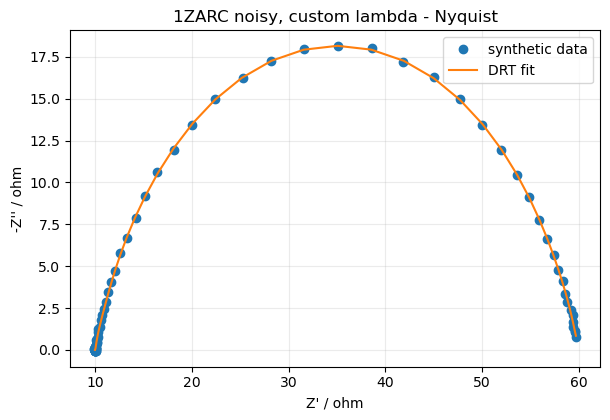

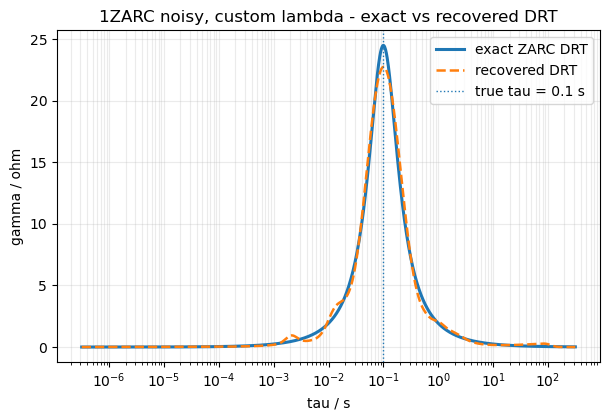

In [10]:
plot_simple_result(entry_noisy_custom, truth_for("1ZARC.csv"), "1ZARC noisy, custom lambda")

## 3. Two-ZARC batch recovery

This loop is the first useful non-GUI batch test. Each spectrum contains a fixed fast ZARC at `tau = 1e-4 s` and a slow ZARC at `tau = 0.1 s`; the slow ZARC resistance changes from 5 to 55 ohm. The pass/fail goal is not perfect peak fitting, but the recovered total polarization resistance and peak locations should track the truth.

In [11]:
batch_entries = {}
batch_rows = []
for filename in [f"2ZARC{n}.csv" for n in range(6)]:
    entry = run_simple(filename, rbf_type="PWL", cv_type="custom", reg_param=1e-4)
    batch_entries[filename] = entry
    batch_rows.append({"file": filename, **recovery_metrics(entry, truth_for(filename), peak_prominence=0.015)})

batch_table = pd.DataFrame(batch_rows)
batch_table

,file,R_inf recovered / ohm,R_inf relative error,R_pol recovered / ohm,R_pol relative error vs full truth,R_pol recovered over tau window / ohm,R_pol exact over tau window / ohm,R_pol window relative error,DRT L1 relative error over tau window,DRT L2 relative error over tau window,max tau-peak error / decades,relative impedance residual,lambda,number of detected peaks
0,2ZARC0.csv,10.123285,0.012329,55.013752,0.000250,55.013752,54.694313,0.005840,0.111846,0.087161,0.2,0.001490,0.0001,2
1,2ZARC1.csv,10.081891,0.008189,65.039443,0.000607,65.039443,64.684711,0.005484,0.094119,0.082265,0.0,0.001289,0.0001,2
2,2ZARC2.csv,10.094319,0.009432,75.106151,0.001415,75.106151,74.675109,0.005772,0.113777,0.097276,0.0,0.001280,0.0001,2
3,2ZARC3.csv,10.129740,0.012974,85.003969,0.000047,85.003969,84.665507,0.003998,0.077473,0.072077,0.0,0.001164,0.0001,2
4,2ZARC4.csv,10.118535,0.011853,94.846016,0.001621,94.846016,94.655905,0.002008,0.093796,0.081750,0.0,0.001017,0.0001,2
5,2ZARC5.csv,10.116980,0.011698,104.807665,0.001832,104.807665,104.646303,0.001542,0.088168,0.080043,0.0,0.000940,0.0001,3


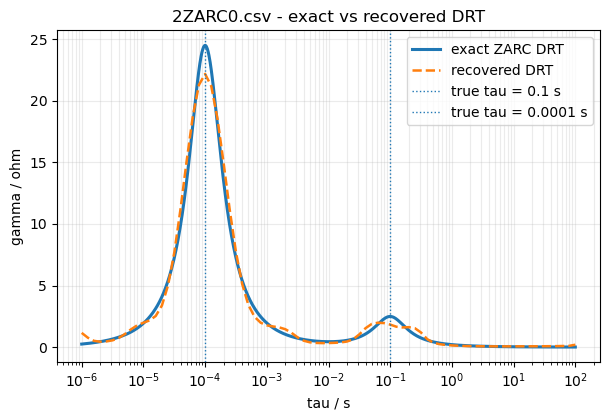

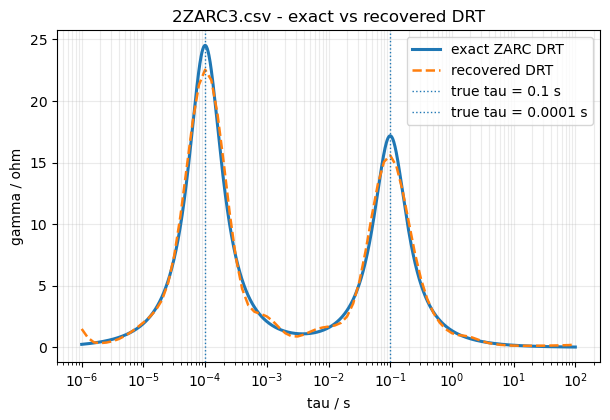

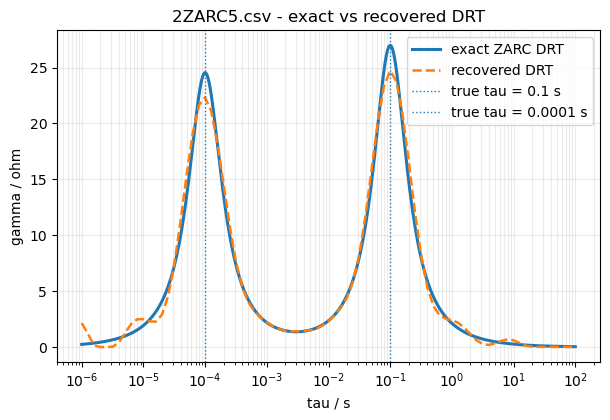

In [12]:
# Show selected two-ZARC recoveries against their exact DRTs.
# These are the most useful plots for judging whether the tutorial recovery is scientifically meaningful.
for filename in ["2ZARC0.csv", "2ZARC3.csv", "2ZARC5.csv"]:
    plot_drt_exact_vs_recovered(batch_entries[filename], truth_for(filename), filename)


## 4. Bayesian credible intervals, small smoke test

The Bayesian sampler is intentionally run on a downsampled spectrum so the notebook remains practical. This cell checks that the credible arrays are finite and ordered. For a full scientific run, increase `NMC_sample` and reduce the downsampling.

In [13]:
bayes_entry = load_entry("1ZARC_exact.csv", every=8)
runs.Bayesian_run(
    bayes_entry,
    rbf_type="PWL",
    data_used="Combined Re-Im Data",
    induct_used=0,
    der_used="1st order",
    cv_type="custom",
    reg_param=1e-4,
    NMC_sample=80,
    burn_in=20,
    rng=np.random.default_rng(42),
)

bayes_checks = {
    "lower finite": bool(np.all(np.isfinite(bayes_entry.lower_bound))),
    "mean finite": bool(np.all(np.isfinite(bayes_entry.mean))),
    "upper finite": bool(np.all(np.isfinite(bayes_entry.upper_bound))),
    "ordered lower <= mean <= upper": bool(
        np.all(bayes_entry.lower_bound <= bayes_entry.mean) and np.all(bayes_entry.mean <= bayes_entry.upper_bound)
    ),
}
pd.DataFrame([bayes_checks])

,lower finite,mean finite,upper finite,ordered lower <= mean <= upper
0,True,True,True,True


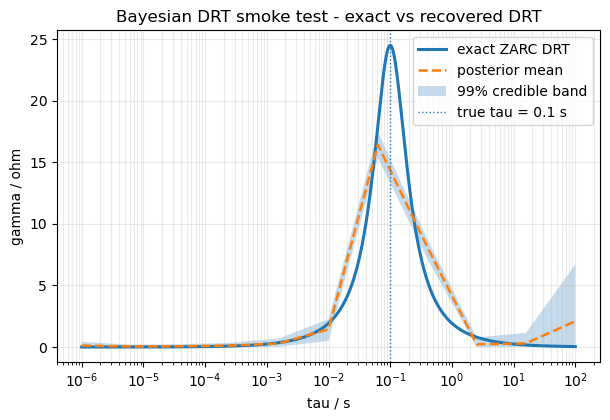

In [14]:
plot_drt_exact_vs_recovered(
    bayes_entry,
    truth_for("1ZARC_exact.csv"),
    "Bayesian DRT smoke test",
    gamma=bayes_entry.mean,
    gamma_label="posterior mean",
    band=(bayes_entry.lower_bound, bayes_entry.upper_bound),
)


## 5. BHT / KK consistency smoke test

BHT can be numerically harder than ridge recovery. The important software check is that it returns a status and does not enter an endless retry loop. On a successful run, the scores should be finite and in the expected probability-score range. These scores are Hilbert/Kramers-Kronig consistency diagnostics; they do not imply that a BHT DRT estimate is available. The GUI and exports should report that no validated BHT DRT estimate is available unless an explicit DRT validation passes.

In [15]:
class FixedThetaRng:
    """Deterministic initial condition provider for BHT tutorial smoke tests."""

    def __init__(self, theta):
        self.theta = np.asarray(theta, dtype=float)

    def uniform(self, size=None):
        values = (np.log10(self.theta) + 3.0) / 6.0
        if size is None:
            return values
        return np.broadcast_to(values.reshape(3, 1), size).copy()


bht_entry = load_entry("1ZARC_exact.csv", every=12)
runs.BHT_run(bht_entry, rbf_type="PWL", rng=FixedThetaRng([0.05185711, 0.00210661, 0.19962424]))

score_values = {key: np.asarray(value, dtype=float) for key, value in bht_entry.out_scores.items()}
bht_summary = {
    "success": bool(bht_entry.result.success),
    "attempts": int(bht_entry.result.attempts),
    "message": bht_entry.result.message,
    "all scores finite": bool(all(np.all(np.isfinite(value)) for value in score_values.values())),
    "scores in [0, 1]": bool(all(np.all(value >= -1e-12) and np.all(value <= 1.0 + 1e-12) for value in score_values.values())),
    "BHT DRT status": "validated" if runs.bht_drt_available(bht_entry) else "unavailable/nonvalidated",
    "BHT DRT message": runs.bht_drt_message(bht_entry),
}
pd.DataFrame([bht_summary])

,success,attempts,message,all scores finite,"scores in [0, 1]"
0,True,1,,True,True


## 6. Run the same checks as a script

Rahul can run this before opening Jupyter. It is the fastest way to check that the core tutorial workflow works locally.

From the repository root on macOS/Linux:

```bash
PYTHONPATH=. python tutorial/run_recovery_checks.py
PYTHONPATH=. python tutorial/run_recovery_checks.py --slow
```

From PowerShell on Windows:

```powershell
$env:PYTHONPATH=(Get-Location).Path
python tutorial/run_recovery_checks.py
python tutorial/run_recovery_checks.py --slow
```

In [16]:
# Optional: run the command-line check from inside the notebook.
# Set RUN_SCRIPT_CHECK = True when you want the script's pass/fail output here.
RUN_SCRIPT_CHECK = False
if RUN_SCRIPT_CHECK:
    env = os.environ.copy()
    env["PYTHONPATH"] = str(ROOT)
    subprocess.run([sys.executable, str(TUTORIAL_DIR / "run_recovery_checks.py")], cwd=str(ROOT), env=env, check=False)

## 7. GUI checklist

Launch the GUI from the local tree, not from an installed package:

macOS/Linux:

```bash
PYTHONPATH=. python launch.py
```

Windows PowerShell:

```powershell
$env:PYTHONPATH=(Get-Location).Path
python launch.py
```

Manual GUI checks:

1. Load `tutorial/data/1ZARC.csv`; confirm the Nyquist arc uses the expected sign convention.
2. Run ridge/simple DRT with combined real-imaginary data and no inductance for the one-ZARC file.
3. Confirm the DRT peak is near `tau = 0.1 s`, `R_inf` is near 10 ohm, and the fitted Nyquist trace overlays the data.
4. Run Bayesian recovery on the same file or a downsampled file if the GUI allows it; confirm credible bands render.
5. Run BHT; confirm it either shows consistency scores or returns a clean failure message, with no endless loop. If scores are available but no BHT DRT validation passed, the DRT view/export should report the BHT DRT as unavailable/nonvalidated.
6. Export DRT and fitted EIS results after a successful run; then test cancelling the export dialog. Cancelling should do nothing and should not crash.
7. Try exporting before any method has run. The GUI should show an error instead of opening a save dialog or crashing.